In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [2]:
df_fe = pd.read_csv("../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)

(369, 22)


# Data Fede, features como filas 

In [176]:
df_fe.head().transpose()

,0,1,2,3,4
timestamp,11/17/2022 8:35:00,11/17/2022 8:36:12,11/17/2022 8:36:21,11/17/2022 8:36:30,11/17/2022 8:36:39
escuela,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani,Escuela Nueva Juan Mantovani
grado,Quinto,Quinto,Quinto,Quinto,Quinto
curso,B,B,B,B,B
edad,10,10,11,10,11
genero,Masculino,Masculino,Masculino,Masculino,Femenino
lugar_computadora,En la escuela,En mi casa,En mi casa,En mi casa,En mi casa
uso_computadora,"Juego juegos, Hago la tarea","Juego juegos, Miro videos en YouTube",Juego juegos,"Juego juegos, Hablo con amigos",Hablo con amigos
aprender_computadora,Me enseñaron en mi casa,Me enseñaron en mi casa,Aprendí solo,Me enseñaron en mi casa,"Me enseñaron en mi casa, Aprendí solo"
dueño_celular,El mío,El mío,El mío,El mío,El mío


# Descripción del grupo

A continuación se describe el grupo encuestado según distintas variables poblacionales. 


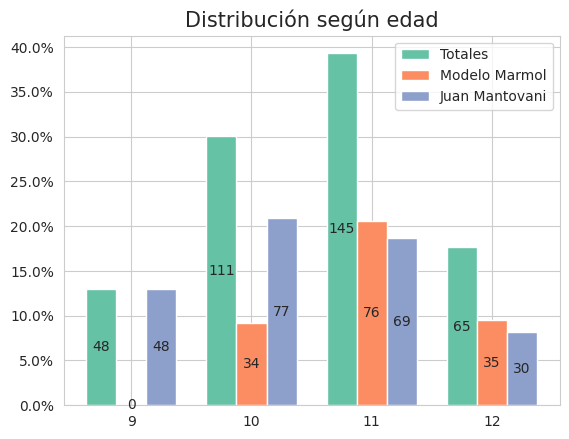

In [125]:
# Distribución según edad
data_total = df_fe["edad"].value_counts().sort_index()
data_marmol = marmol["edad"].value_counts().sort_index()
data_marmol[9] = 0
data_marmol = data_marmol.sort_index()
data_mantovani = mantovani["edad"].value_counts().sort_index()

labels = [data_total.to_numpy(), data_marmol.to_numpy(), data_mantovani.to_numpy()]

fig, ax = plt.subplots()

bar_width = 0.25
br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
plt.bar(br1,data_total.div(cant_total), width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol.div(cant_total), width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani.div(cant_total), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=labels[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según edad", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('poblacional_edad.png')

Los números en las columnas son cantidades de niñes por edad.
Los porcentajes son en base a cantidades totales (% del total de 369 niñes).
No hay chicas/os de 9 años en el Modelo Mármol. Tiene sentido pues no tenemos chiques de cuarto grado.
Hay poco más del doble de niñes de 10 años en el Mantovani que el Modelo. Tiene sentido pues la mitad de los chicos de Cuarto grado tienen 10 años.
Las cantidades de chicos y chicas de 11 y 12 años están similarmente distribuidas.

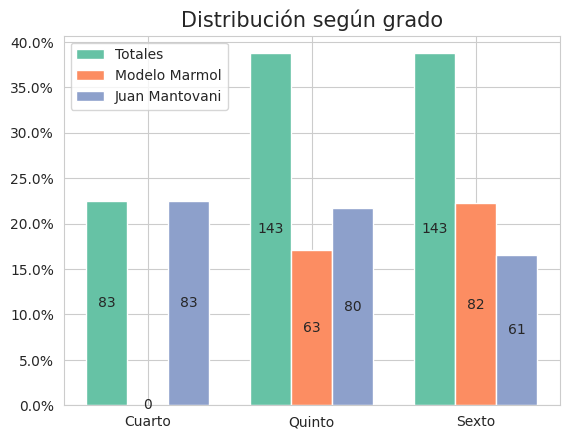

In [115]:
# Distribución según grado
data_total = df_fe["grado"].value_counts().sort_index()

data_marmol = marmol["grado"].value_counts().sort_index()
data_marmol["Cuarto"] = 0
data_marmol = data_marmol.sort_index()

data_mantovani = mantovani["grado"].value_counts().sort_index()

labels = [data_total.to_numpy(), data_marmol.to_numpy(), data_mantovani.to_numpy()]

bar_width = 0.25
br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,data_total.div(cant_total), width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol.div(cant_total), width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani.div(cant_total), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=labels[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según grado", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()

plt.savefig('poblacional_grado.png')


Los números en las columnas son cantidades de niñes por grado.
Los porcentajes son en base a cantidades totales (% del total de 369 niñes).
Alumnas/os de quinto y sexto similarmente distribuidos.
No tenemos alumnas/os en cuarto grado en el Modelo Mármol.
Cantidad similar de alumnas/os de cuarto grado a los quintos y sextos.

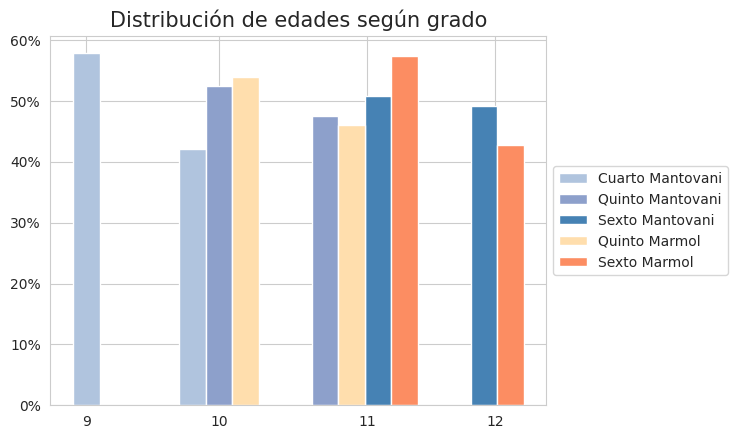

In [61]:
# Distribución de edades según grado 
data_total = df_fe["edad"].value_counts(normalize=True).sort_index()

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["edad"].value_counts(normalize=True).sort_index()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["edad"].value_counts(normalize=True).sort_index()

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["edad"].value_counts(normalize=True).sort_index()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["edad"].value_counts(normalize=True).sort_index()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["edad"].value_counts(normalize=True).sort_index()

for data in data_total.index:
    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = np.nan
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = np.nan

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = np.nan
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = np.nan
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = np.nan


data_marmol_quinto = data_marmol_quinto.sort_index()
data_marmol_sexto = data_marmol_sexto.sort_index()

data_mantovani_cuarto = data_mantovani_cuarto.sort_index()
data_mantovani_quinto = data_mantovani_quinto.sort_index()
data_mantovani_sexto = data_mantovani_sexto.sort_index()

bar_width = 0.25
br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]
plt.bar(br2,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br3,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')
plt.bar(br4,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br6,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución de edades según grado", fontsize=15)
ticks = [0.25, 1.5, 2.9, 4.1]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('3.png')

# Agregar totales. Aclarar grafico

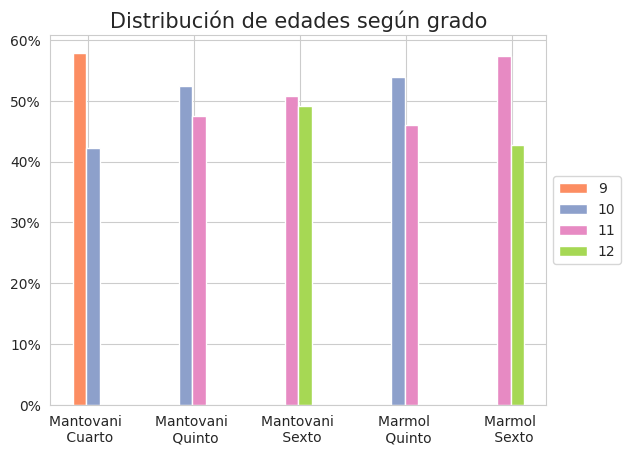

In [60]:
# Distribución de edades según grado, otra version

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["edad"].value_counts(normalize=True)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["edad"].value_counts(normalize=True)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["edad"].value_counts(normalize=True)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["edad"].value_counts(normalize=True)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["edad"].value_counts(normalize=True)

ticks = [1, 3, 5, 7, 9]
labels = ['Mantovani \n Cuarto', 'Mantovani \n Quinto', 'Mantovani \n Sexto',
    'Marmol \n Quinto', 'Marmol \n Sexto']
bar_width = 0.25

nueve = [data_mantovani_cuarto[9]]
diez  = [data_mantovani_cuarto[10], data_mantovani_quinto[10], data_marmol_quinto[10]]
once  = [data_mantovani_quinto[11], data_mantovani_sexto[11], data_marmol_quinto[11], data_marmol_sexto[11]]
doce  = [data_mantovani_sexto[12], data_marmol_sexto[12]]

plt.bar([1], nueve, width=bar_width, label = '9', color='C1')

plt.bar([1.25, 3, 7], diez, width=bar_width, label = '10', color='C2')

plt.bar([3.25, 5, 7.25, 9], once,  width=bar_width, label = '11', color='C3')

plt.bar([5.25, 9.25], doce,  width=bar_width, label = '12', color='C4')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución de edades según grado", fontsize=15)
# ticks = [0.25, 1.5, 2.9, 4.1]
plt.xticks([x + 0.15 for x in ticks], labels)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('3.1.png')

# todo
# agrupar quintos y sextos

En cuarto grado solo hay datos del Mantovani. La distribución de edades está en un 58% con 9 años y un 42% con 10 años.
En quinto grado las edades están balanceadas en ambos colegios. Al rededor de la mitad de los chicos tiene un año menos que sus compañeras/os en ambos colegios.
En sexto grado las edades están balanceadas en el Mantovani, pero en el Modelo Mármol vemos un 57% con 11 años y un 43% con 11 años.

`probar con la misma distribucion en base a edad`

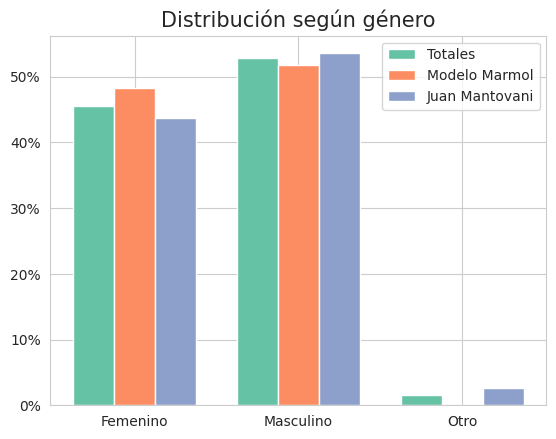

In [180]:
# Distribución según género
data_total = df_fe["genero"].value_counts(normalize=True).sort_index()
data_marmol = marmol["genero"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["genero"].value_counts(normalize=True).sort_index()

data_marmol["Otro"] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según género", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('4.png')

# agregar cantidades totales en este grafico

La distribución de géneros es uniforme en cuanto a cantidades totales.

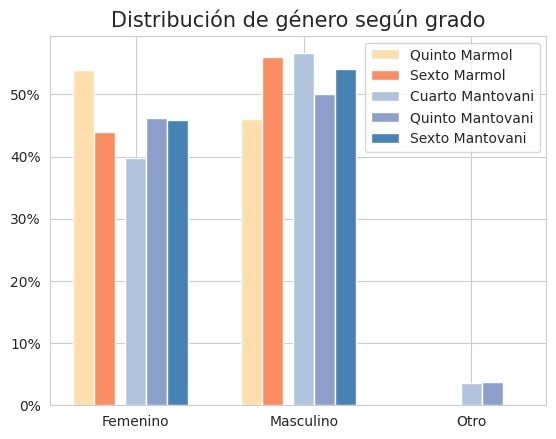

In [181]:
# Distribución de genero según grado 
data_total = df_fe["genero"].value_counts(normalize=True).sort_index()

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["genero"].value_counts(normalize=True).sort_index()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["genero"].value_counts(normalize=True).sort_index()

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["genero"].value_counts(normalize=True).sort_index()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["genero"].value_counts(normalize=True).sort_index()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["genero"].value_counts(normalize=True).sort_index()

for data in data_total.index:

    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

data_marmol_quinto = data_marmol_quinto.sort_index()
data_marmol_sexto = data_marmol_sexto.sort_index()

data_mantovani_cuarto = data_mantovani_cuarto.sort_index()
data_mantovani_quinto = data_mantovani_quinto.sort_index()
data_mantovani_sexto = data_mantovani_sexto.sort_index()

bar_width = 0.25
ticks = [1, 3, 5]
br1 = ticks
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br3,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br4,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br5,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br6,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución de género según grado", fontsize=15)
ticks = [x + 3.5*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('5.png')

El cuerto grado del Mantovani tiene una distribución mayor de varones que mujeres, un 60-40.
Quinto y Sexto de ambos colegios tienen una distribución de entre 45-55 por lo que están bien distribuídos.
El género Otro no tiene grandes porcentajes en ningún grado.

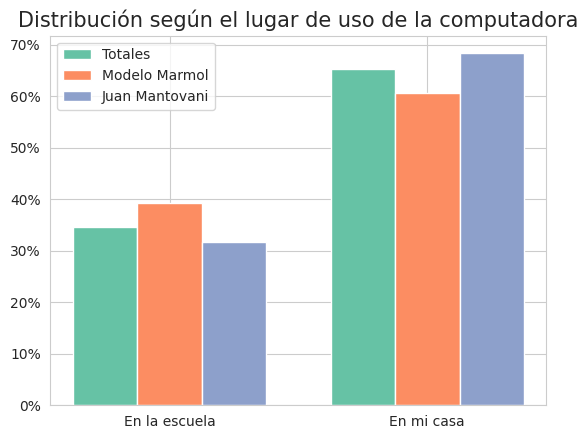

In [182]:
# Lugar de uso de la computadora
data_total = df_fe["lugar_computadora"].value_counts(normalize=True).sort_index()
data_marmol = marmol["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["lugar_computadora"].value_counts(normalize=True).sort_index()

# data_marmol["No la uso"] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el lugar de uso de la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('6.png')

Al rededor de un tercio usa la computadora mayormente en la escuela. El resto lo hace en su casa.

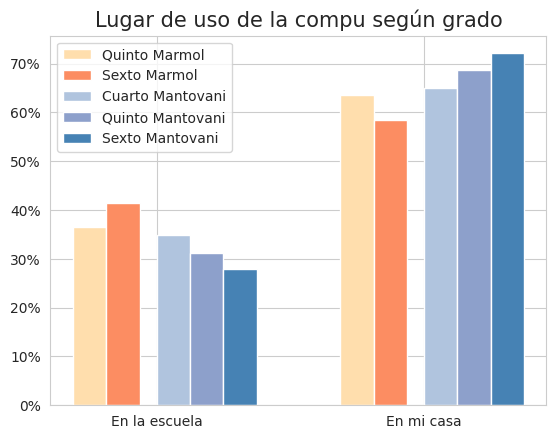

In [183]:
# Lugar de uso de la compu según grado
data_total = df_fe["lugar_computadora"].value_counts(normalize=True).sort_index()

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["lugar_computadora"].value_counts(normalize=True).sort_index()

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["lugar_computadora"].value_counts(normalize=True).sort_index()

for data in data_total.index:

    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

data_marmol_quinto = data_marmol_quinto.sort_index()
data_marmol_sexto = data_marmol_sexto.sort_index()

data_mantovani_cuarto = data_mantovani_cuarto.sort_index()
data_mantovani_quinto = data_mantovani_quinto.sort_index()
data_mantovani_sexto = data_mantovani_sexto.sort_index()

bar_width = 0.25
ticks = [1, 3]

br1 = ticks
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br3,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br4,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br5,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br6,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Lugar de uso de la compu según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('7.png')

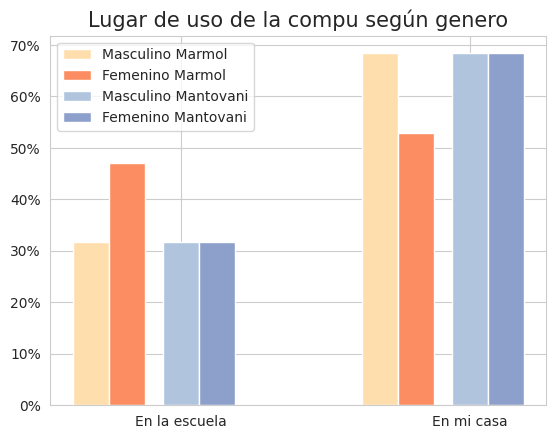

In [4]:
# lugar de uso de la compu segun genero
data_total = df_fe["lugar_computadora"].value_counts(normalize=True).sort_index()

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["lugar_computadora"].value_counts(normalize=True).sort_index()

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["lugar_computadora"].value_counts(normalize=True).sort_index()
# data_mantovani_otr = mantovani[mantovani['genero']=="Otro"]["lugar_computadora"].value_counts(normalize=True).sort_index()

dfs = [data_mantovani_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
    #    data_mantovani_otr]

for data in data_total.index:
    for df in dfs:
        if data not in df.index:
            df[data] = 0.0
        df = df.sort_index()

bar_width = 0.25
ticks = [1, 3]
br1 = ticks
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
# br6 = [x + bar_width for x in br5]

plt.bar(br2,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br3,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')

plt.bar(br4,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br5,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')
# plt.bar(br6,dfs[4], width=bar_width, label = 'Otro Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Lugar de uso de la compu según genero", fontsize=15)
ticks = [x + 3.5*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('5.1.png')

# Aclarar por que sacamos el genero otro

# Fede
Es un grupo con muchos niñes de 11 años, principalmente en el Modelo Marmol. Con respecto al género, están bien distribuidos en el Mantovani y hay un % mayor de varones en el Modelo Mármol.

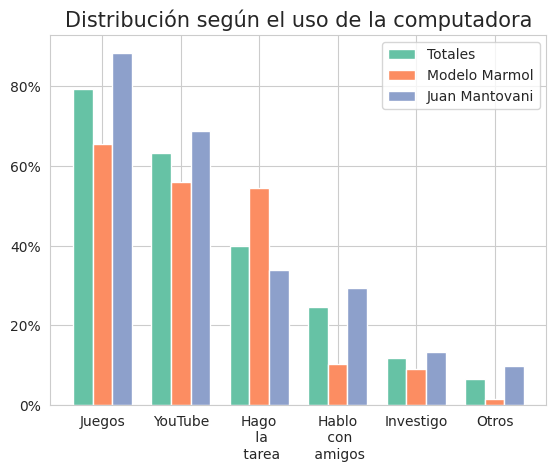

In [184]:
# Uso de la computadora
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

dfs = [data_total, data_marmol, data_mantovani]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Hablo\n con\n amigos", "Investigo", "Otros")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el uso de la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('8.png')

En cuanto a los usos comunes vemos una leve diferencia entre colegios. Jugar juegos y Youtube son las opciones más elegidas; Hay diferencias marcadas entre los porcentajes de chicos que usan la computadora para hacer la tarea, hablar con amigos y jugar juegos entre colegios. También vemos que en ambos colegios un porcentaje cerca del 10% selecciona la nueva opción de Investigar en Wikipedia/Google según sus intereses particulares. Se agruparon las respuestas "Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica" en la categoría otros pues no representaban una porción interesante de la data total
`Podríamos comparar usos de la computadora entre cursos y ver que cambios se notan entre ellos`


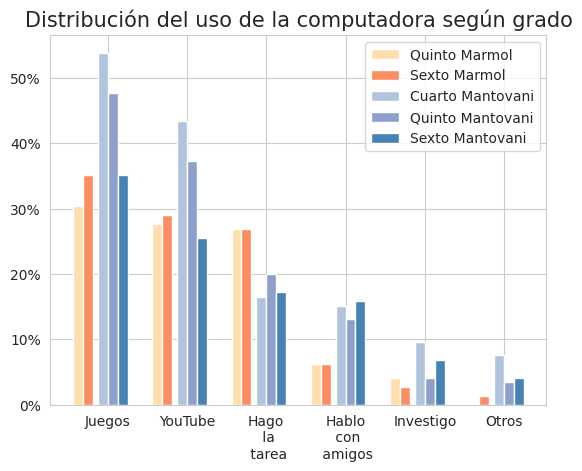

In [8]:
# Uso de la computadora según grado
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

dfs = [data_total, data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

for data in data_total.index:
    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Hablo\n con\n amigos", "Investigo", "Otros")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br_mantovani_cuarto,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución del uso de la computadora según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
[id for id in data_total.sort_index().index]
plt.legend()
plt.savefig('9.png')

# realizar grafico con distribucion segun genero y 

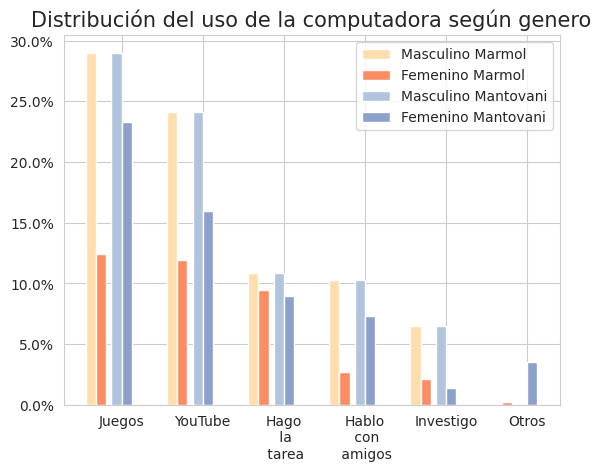

In [14]:
# Uso de la compu segun genero
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
# data_mantovani_otr = mantovani[mantovani['genero']=="Otro"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

dfs = [data_mantovani_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
    #    , data_mantovani_otr]
otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

# for data in data_total.index:
#     for df in dfs:
#         if data not in df.index:
#             df[data] = 0.0
        # df = df.sort_index()


bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11]

labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
            "Hablo\n con\n amigos", "Investigo", "Otros")


# bar_width = 0.25
# ticks = [1, 3]
br1 = ticks
br2 = [x + bar_width for x in br1]
# br3 = [x + bar_width for x in br2]

br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]
# br5 = [x + bar_width for x in br4]

# for df in dfs:
#     print(df)

plt.bar(br1,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')

plt.bar(br3,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')
# plt.bar(br5,dfs[4], width=bar_width, label = 'Otro Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("Distribución del uso de la computadora según genero", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('9.1.png')

# Explicar el mas elegido de otros en este grafico -> desgloce de otros.
# Cantidad de opciones elegidas por genero

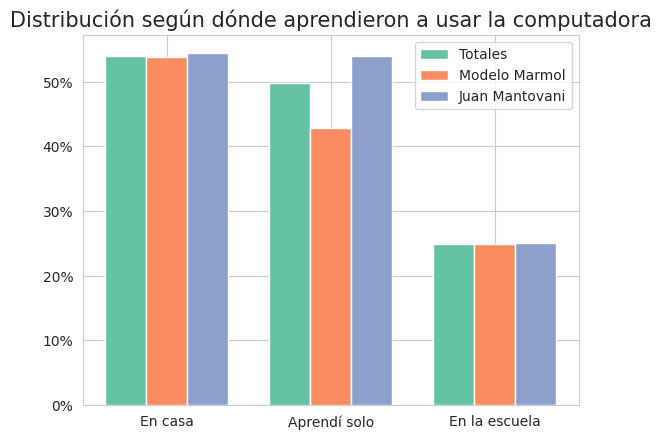

In [186]:
# Donde aprendiste a uisar la computadora
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("En casa", "Aprendí solo", "En la escuela")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según dónde aprendieron a usar la computadora", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('10.png')

Las opciones más elegidas son _"Me enseñaron en mi casa (mis padres, hermanos u otro familiar)"_ y _"Aprendí solo"_. Nuevamente queda para la siguiente iteracion `comparar respuestas entre cursos y ver que cambios se notan entre ellos`

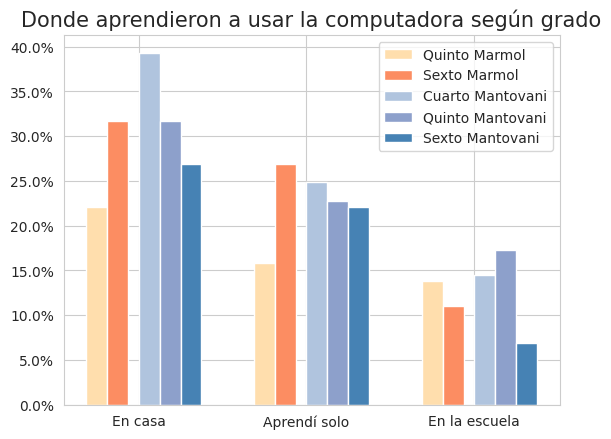

In [10]:
# Donde aprendieron a usar la computadora segun grado

# Uso de la computadora según grado
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

for data in data_total.index:
    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

bar_width = 0.25

ticks = [1, 3, 5]

labels = ("En casa", "Aprendí solo", "En la escuela")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br_mantovani_cuarto,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Donde aprendieron a usar la computadora según grado", fontsize=15)
ticks = [x + 2*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('11.png')

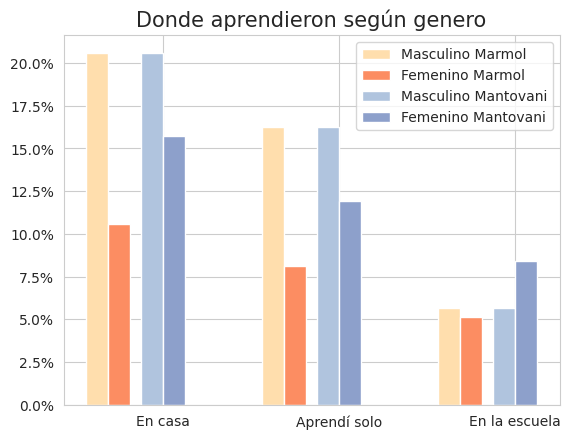

In [16]:
# donde aprendieron segun genero
data_total = df_fe["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
# data_mantovani_otr = mantovani[mantovani['genero']=="Otro"]["aprender_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

dfs = [data_mantovani_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
    #    , data_mantovani_otr]
# otros = ["Programo/Diseño", "Usoredessociales", "MiroPelis/Seriesporstreaming", "Escuchomúsica"]

# for df in dfs:
#     df["Otros"] = 0.0
#     for data in df.index:
#         if data in otros:
#             df["Otros"] = df["Otros"] + df[data]
#             df.drop(data, inplace=True)

for data in data_total.index:
    for df in dfs:
        if data not in df.index:
            df[data] = 0.0
        # df = df.sort_index()



bar_width = 0.25

ticks = [1, 3, 5]

labels = ("En casa", "Aprendí solo", "En la escuela")

# br_marmol_quinto = ticks
# br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

# br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
# br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
# br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]


# bar_width = 0.25

# ticks = [1, 3, 5, 7, 9, 11]

# labels = ("Juegos", "YouTube", "Hago\n la\n tarea", \
#             "Hablo\n con\n amigos", "Investigo", "Otros")


# bar_width = 0.25
# ticks = [1, 3]
br1 = ticks
br2 = [x + bar_width for x in br1]
# br3 = [x + bar_width for x in br2]

br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]
# br5 = [x + bar_width for x in br4]

# for df in dfs:
#     print(df)

plt.bar(br1,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')

plt.bar(br3,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')
# plt.bar(br5,dfs[4], width=bar_width, label = 'Otro Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.title("Donde aprendieron según genero", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('11.1.png')

# Agregar
# Cantidad de respuestas que seleccionan segun genero

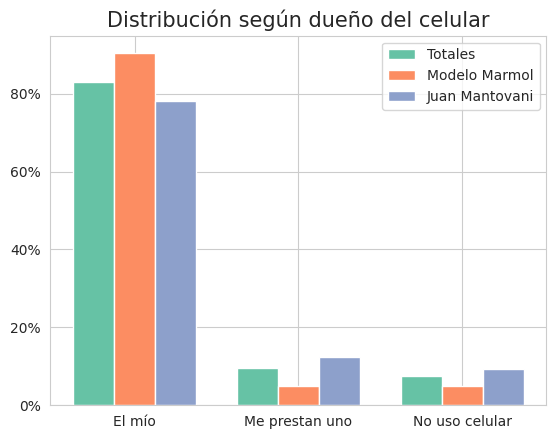

In [188]:
# Distribución según dueño del celular
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol = marmol["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani = mantovani["dueño_celular"].value_counts(normalize=True).sort_index()

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según dueño del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('12.png')

La gran mayoría tiene celular propio

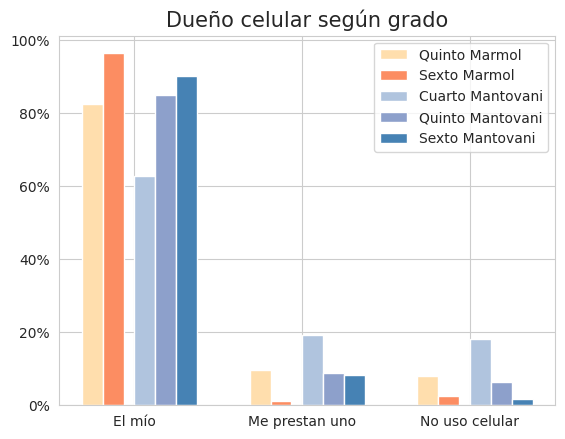

In [22]:
# Dueño celular segun grado
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["dueño_celular"].value_counts(normalize=True).sort_index()

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["dueño_celular"].value_counts(normalize=True).sort_index()

for data in data_total.index:

    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

data_marmol_quinto = data_marmol_quinto.sort_index()
data_marmol_sexto = data_marmol_sexto.sort_index()

data_mantovani_cuarto = data_mantovani_cuarto.sort_index()
data_mantovani_quinto = data_mantovani_quinto.sort_index()
data_mantovani_sexto = data_mantovani_sexto.sort_index()

bar_width = 0.25
ticks = [1, 3, 5]

# br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in ticks]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br3,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br4,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br5,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br6,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dueño celular según grado", fontsize=15)
ticks = [x + 3*bar_width for x in br1]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('12.1.png')

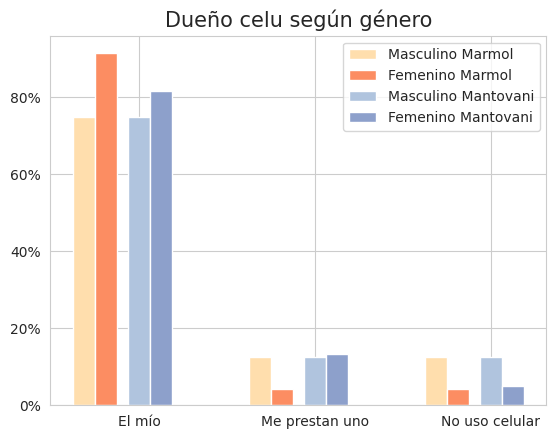

In [20]:
# due;o celu segun genero
data_total = df_fe["dueño_celular"].value_counts(normalize=True).sort_index()

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["dueño_celular"].value_counts(normalize=True).sort_index()

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["dueño_celular"].value_counts(normalize=True).sort_index()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["dueño_celular"].value_counts(normalize=True).sort_index()
# data_mantovani_otr = mantovani[mantovani['genero']=="Otro"]["dueño_celular"].value_counts(normalize=True).sort_index()

dfs = [data_mantovani_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
    #    , data_mantovani_otr]

for data in data_total.index:
    for df in dfs:
        if data not in df.index:
            df[data] = 0.0
        df = df.sort_index()

bar_width = 0.25
ticks = [1, 3, 5]

# br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in ticks]
br3 = [x + bar_width for x in br2]

br4 = [x + 1.5*bar_width for x in br3]
br5 = [x + bar_width for x in br4]
br6 = [x + bar_width for x in br5]

plt.bar(br2,dfs[0], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br3,dfs[1], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br4,dfs[2], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br5,dfs[3], width=bar_width, label = 'Femenino Mantovani', color='C2')
# plt.bar(br6,dfs[4], width=bar_width, label = 'Otro Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dueño celu según género", fontsize=15)
ticks = [x + 3.5*bar_width for x in ticks]
plt.xticks(ticks, [id for id in data_total.sort_index().index])
plt.legend()
plt.savefig('12.2.png')

# pensar como mostrar progresion ded dueño de celular a medida que avanzan en grado
# un grafico por colegio primera iteracion? los ponemos al lado del otro?

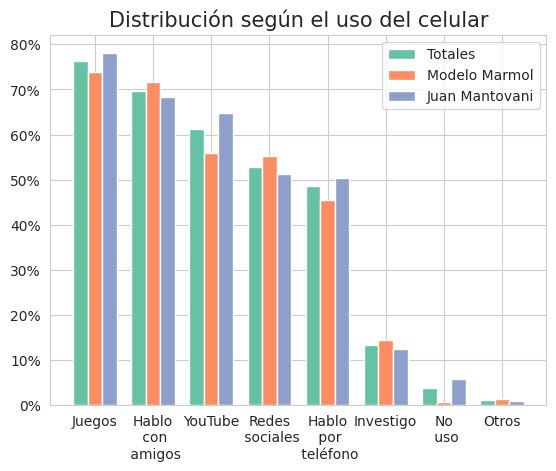

In [190]:
# Distribución uso del celular
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

otros = ["Hagolatarea", "Programo/Diseño"]

dfs = [data_total, data_marmol, data_mantovani]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

for data in data_total.index:
    if data not in data_marmol.index:
        data_marmol[data] = 0.0
    if data not in data_mantovani.index:
        data_mantovani[data] = 0.0

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

labels = ("Juegos", "Hablo\n con\n amigos", "YouTube", "Redes\n sociales", \
           "Hablo\n por\n teléfono", "Investigo", "No\n uso", "Otros")

plt.bar(br1,data_total, width=bar_width, label = 'Totales')
plt.bar(br2,data_marmol, width=bar_width, label = 'Modelo Marmol')
plt.bar(br3,data_mantovani, width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución según el uso del celular", fontsize=15)
plt.xticks([r + bar_width for r in range(len(data_total))], labels)
plt.legend()
plt.savefig('13.png')

La gran mayoría Juega Juegos y Habla con amigos. Los usos frecuentes son similares en ambos colegios. Nuevamente un porcentaje menor elige la opción de investigar por su cuenta. Se agruparon en la sección "Otros" la opción de Hacer la tarea y Programar/diseñar

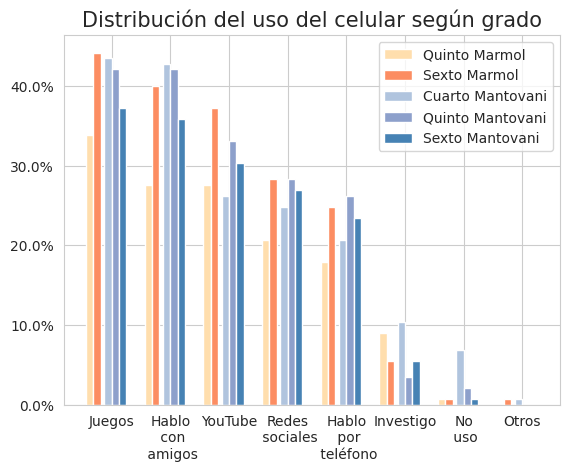

In [36]:
# Uso del celular según grado
data_total = df_fe["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_celular"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)

otros = ["Hagolatarea", "Programo/Diseño"]

dfs = [data_total, data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

for data in data_total.index:
    if data not in data_marmol_quinto.index:
        data_marmol_quinto[data] = 0.0
    if data not in data_marmol_sexto.index:
        data_marmol_sexto[data] = 0.0

    if data not in data_mantovani_cuarto.index:
        data_mantovani_cuarto[data] = 0.0
    if data not in data_mantovani_quinto.index:
        data_mantovani_quinto[data] = 0.0
    if data not in data_mantovani_sexto.index:
        data_mantovani_sexto[data] = 0.0

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11, 13, 15]

labels = ("Juegos", "Hablo\n con\n amigos", "YouTube", "Redes\n sociales", \
           "Hablo\n por\n teléfono", "Investigo", "No\n uso", "Otros")

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,data_marmol_quinto, width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br_marmol_sexto,data_marmol_sexto, width=bar_width, label = 'Sexto Marmol', color='C1')

plt.bar(br_mantovani_cuarto,data_mantovani_cuarto, width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto,data_mantovani_quinto, width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,data_mantovani_sexto, width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución del uso del celular según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('13.1.png')

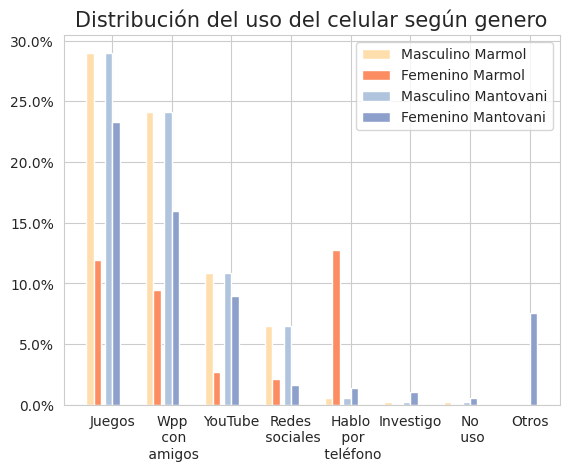

In [25]:
#uso celu segun genero
data_total = df_fe["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
# data_mantovani_otr = mantovani[mantovani['genero']=="Otro"]["uso_computadora"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

dfs = [data_total, data_mantovani_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]
    #    , data_mantovani_otr]
otros = ["Hagolatarea", "Programo/Diseño"]

for df in dfs:
    df["Otros"] = 0.0
    for data in df.index:
        if data in otros:
            df["Otros"] = df["Otros"] + df[data]
            df.drop(data, inplace=True)

for data in data_total.index:
    for df in dfs:
        # print(df)
        if data not in df.index:
            df[data] = 0.0

bar_width = 0.25

ticks = [1, 3, 5, 7, 9, 11, 13, 15]

labels = ("Juegos", "Wpp\n con\n amigos", "YouTube", "Redes\n sociales", \
           "Hablo\n por\n teléfono", "Investigo", "No\n uso", "Otros")

b1 = ticks
b2 = [x + bar_width for x in b1]
b3 = [x + 1.5* bar_width for x in b2]
b4 = [x + bar_width for x in b3]
# b5 = [x + bar_width for x in b4]

plt.bar(b1,dfs[1], width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(b2,dfs[2], width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(b3,dfs[3], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(b4,dfs[4], width=bar_width, label = 'Femenino Mantovani', color='C2')
# plt.bar(b5,dfs[5], width=bar_width, label = 'Otro Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Distribución del uso del celular según genero", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, labels)
plt.legend()
plt.savefig('13.2.png')

# Separar en otros
# cambiar hablo con amigos por videollamada/whatsapp